In [ ]:

import warnings; warnings.filterwarnings("ignore")
import os

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
!pip install pennylane pennylane-lightning --upgrade -q

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch: {torch.__version__} CUDA: {torch.cuda.is_available()}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 81.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 105.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 12.9 MB/s eta 0:00:00
PyTorch: 2.10.0+cu128 CUDA: True


In [2]:
INPUT_DIR = "/kaggle/input/datasets/parthenaik/q-sentinel/quantum-sentinel"
OUTPUT_DIR = Path("/kaggle/working"); OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
scripts_dir = "/kaggle/input/datasets/parthenaik/qsentinal-scripts"
if scripts_dir not in sys.path: sys.path.append(scripts_dir)

import scripts

print("scripts loaded from:", scripts.__file__)

scripts loaded from: /kaggle/input/datasets/parthenaik/qsentinal-scripts/scripts/__init__.py


In [ ]:



from scripts.cache import (
    ForwardCache,
    cached_calibrate_threshold,
    cached_conformal_alpha_sweep,
    cached_lipschitz_percentile,
    cached_qsnet_infer,
)
from scripts.circuit import build_forward_circuit, create_quantum_device
from scripts.constants import (
    BARREN_PLATEAU_VAR_THRESHOLD,
    DEFAULT_ALPHA,
    DEFAULT_BATCH_SIZE,
    DEFAULT_CF,
    DEFAULT_NOISE_RATE,
    DEFAULT_REUPLOAD,
    ZERO_DAY,
)
from scripts.data import (
    capped_sample,
    greedy_dpp_sample,
    load_split,
    to_angles,
)
from scripts.gradient import gradient_variance_probe
from scripts.hilbert import hilbert_geometry_diagnostics, print_h1_report
from scripts.inference import predict_labels
from scripts.logging import write_history_log
from scripts.memory import is_oom_error, run_batched_safely, safe_empty_cache
from scripts.prototypes import prototype_summary
from scripts.quantum_metrics import trace_distance
from scripts.sweep import run_sweep
from scripts.train import train_maqt
from scripts.utils import get_torch_device, to_np_y

print("imports OK")

imports OK


In [ ]:

NOTEBOOK_NAME = "maqt-hptuned-bot-iot"
dataset = "BoT-IoT"
target_col = "label_multiclass"
DATA_DIR = "/kaggle/input/datasets/parthenaik/q-sentinel/quantum-sentinel/data/FROZEN/BOT-IOT"
FROZEN_JSON_PATH = f"{INPUT_DIR}/team-artifacts/teamC_week3_FROZEN_handoff.json"

OUT_DIR = OUTPUT_DIR / "models" / "prototypes" / dataset; OUT_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR = OUTPUT_DIR / "logs"; LOG_DIR.mkdir(parents=True, exist_ok=True)

handoff = json.loads(Path(FROZEN_JSON_PATH).read_text())
FEATURE_COLS = list(handoff["frozen_subsets"][dataset]["features"])
print(f"selector={handoff['frozen_subsets'][dataset]['selector']} k={len(FEATURE_COLS)}")

X_train_full, y_train_full, class_names, df_train = load_split(
    DATA_DIR, "train", target_col, csv=True, selected_cols=FEATURE_COLS, return_df=True)
X_cal_full, y_cal_full, _, df_cal = load_split(
    DATA_DIR, "calibration", target_col, csv=True, selected_cols=FEATURE_COLS, return_df=True)
X_test_full, y_test_full, _, df_test = load_split(
    DATA_DIR, "test", target_col, csv=True, selected_cols=FEATURE_COLS, return_df=True)
X_zero_full, y_zero_full, _, df_zero = load_split(
    DATA_DIR, "zeroday", target_col, csv=True, selected_cols=FEATURE_COLS, return_df=True)

print(f"train {X_train_full.shape} cal {X_cal_full.shape} test {X_test_full.shape} zero {X_zero_full.shape}")
print(f"classes: {class_names}")
num_classes = len(class_names)
DDOS_ID = class_names.index("DDoS")
DOS_ID = class_names.index("DoS")

selector=QIGPSO k=10
train (148729, 10) cal (18591, 10) test (18591, 10) zero (683, 10)
classes: ['DDoS', 'DoS', 'Normal', 'Reconnaissance']


In [ ]:

scaler = StandardScaler()
X_train_full_scaled = scaler.fit_transform(X_train_full)

USE_PCA, TARGET_VARIANCE = True, 0.95
pca_full = PCA(random_state=SEED).fit(X_train_full_scaled)
cum = np.cumsum(pca_full.explained_variance_ratio_)
k95 = min(int(np.searchsorted(cum, TARGET_VARIANCE) + 1), len(cum))
print(f"k95 components: {k95}")

pca = PCA(n_components=k95, random_state=SEED)
X_train_full_feat = pca.fit_transform(X_train_full_scaled)
x_min, x_max = X_train_full_feat.min(0), X_train_full_feat.max(0)

SUBSET, PER_CLASS_CAP = True, 7000
if SUBSET:
    X_train, y_train = greedy_dpp_sample(X_train_full, y_train_full, per_class_cap=PER_CLASS_CAP, seed=SEED)
else:
    X_train, y_train = X_train_full, y_train_full
print(f"train coreset: {X_train.shape}")

def _to_ang(X): return to_angles(X, scaler, x_min, x_max, pca=pca, angle_max=np.pi)

X_train_angles = _to_ang(X_train)
X_cal_angles   = _to_ang(X_cal_full)
X_test_angles  = _to_ang(X_test_full)
X_zero_angles  = _to_ang(X_zero_full)
print("angle shapes:", X_train_angles.shape, X_cal_angles.shape, X_test_angles.shape, X_zero_angles.shape)

k95 components: 5
train coreset: (22359, 10)
angle shapes: (22359, 5) (18591, 5) (18591, 5) (683, 5)


In [ ]:

num_qubits = int(k95)
num_layers = 3
noise_rate = DEFAULT_NOISE_RATE
REUPLOAD = DEFAULT_REUPLOAD

device = get_torch_device()
dev = create_quantum_device(num_qubits)
forward_circuit = build_forward_circuit(dev, num_qubits, num_layers, noise_rate=noise_rate, reupload=REUPLOAD)
print(f"device={device} wires={num_qubits}")

safe_empty_cache()
try:
    grad_var, _ = gradient_variance_probe(
        forward_circuit, X_train_angles[:1], num_qubits, num_layers,
        n_trials=5, device=torch.device("cpu"),
    )
    print(f"pre-train grad var = {grad_var:.2e} (thr={BARREN_PLATEAU_VAR_THRESHOLD:.0e})")
except RuntimeError as e:
    if is_oom_error(e): safe_empty_cache()
    else: raise

device=cuda wires=5
pre-train grad var = 5.57e-14 (thr=1e-06)


In [ ]:

SWEEP_CAP = 1000       
SWEEP_EPOCHS = 5
SWEEP_BATCH = 16         
SWEEP_LR_FIXED_LAMBDA1 = 0.5  

X_train_sweep, y_train_sweep = capped_sample(X_train_full, y_train_full, per_class_cap=SWEEP_CAP, seed=SEED)
X_sweep_angles = _to_ang(X_train_sweep)
print(f"sweep subset: {X_sweep_angles.shape}")

def train_fn_sweep(lambda2_max, lr):
    torch.manual_seed(SEED)
    theta, head, prototypes, ema_protos, history = train_maqt(
        X_sweep_angles, y_train_sweep,
        n_classes=num_classes, n_qubits=num_qubits, n_layers=num_layers,
        forward_circuit=forward_circuit, device=device,
        epochs=SWEEP_EPOCHS, lr=lr, batch_size=SWEEP_BATCH,
        lambda1_max=SWEEP_LR_FIXED_LAMBDA1, lambda2_max=lambda2_max,
        use_weighted_sampler=True, seed=SEED,
        early_stopping=False, checkpoint_dir=None, save_every_epoch=False,
        verbose=False, heartbeat_every_steps=0,
        notebook_name="hp_sweep", log_dir=str(LOG_DIR / "sweep"),
    )
    return theta, head, prototypes, ema_protos, history

sweep subset: (4000, 5)


In [ ]:

# HP sweep, scored on DDoS<->DoS prototype separation

def ddos_dos_score_fn(history, prototypes):
    if DDOS_ID not in prototypes or DOS_ID not in prototypes:
        return float("-inf")
    pair_td = float(trace_distance(prototypes[DDOS_ID], prototypes[DOS_ID]))
    stable = min(history["grad_var"]) > BARREN_PLATEAU_VAR_THRESHOLD
    # weight: DDoS/DoS separation primary, overall inter/intra geometry secondary
    return (
        1.0 * pair_td
        + 0.3 * history["inter_trace_dist"][-1]
        + 0.2 * history["intra_fid_gap"][-1]
        - (0 if stable else 1)
    )

LAMBDA2_GRID = [0.1, 0.3, 0.6, 1.0]
LR_GRID = [0.005, 0.01, 0.02]
param_grid = [{"lambda2_max": l2, "lr": lr} for l2 in LAMBDA2_GRID for lr in LR_GRID]

print(f"sweeping {len(param_grid)} configs (lambda2 x lr)...")
sweep_df = run_sweep(train_fn_sweep, param_grid, ddos_dos_score_fn)
sweep_df

sweeping 12 configs (lambda2 x lr)...
{'lambda2_max': 0.1, 'lr': 0.005} -> score=0.4555
{'lambda2_max': 0.1, 'lr': 0.01} -> score=0.4549
{'lambda2_max': 0.1, 'lr': 0.02} -> score=0.4478
{'lambda2_max': 0.3, 'lr': 0.005} -> score=0.4555
{'lambda2_max': 0.3, 'lr': 0.01} -> score=0.4549
{'lambda2_max': 0.3, 'lr': 0.02} -> score=0.4478
{'lambda2_max': 0.6, 'lr': 0.005} -> score=0.4555
{'lambda2_max': 0.6, 'lr': 0.01} -> score=0.4549
{'lambda2_max': 0.6, 'lr': 0.02} -> score=0.4478
{'lambda2_max': 1.0, 'lr': 0.005} -> score=0.4555
{'lambda2_max': 1.0, 'lr': 0.01} -> score=0.4549
{'lambda2_max': 1.0, 'lr': 0.02} -> score=0.4478


,lambda2_max,lr,score,final_loss,final_intra_fid,min_grad_var
0,0.1,0.005,0.455509,0.708054,0.835642,0.000715
3,0.3,0.005,0.455509,0.599376,0.835642,0.000715
9,1.0,0.005,0.455509,0.219007,0.835642,0.000715
6,0.6,0.005,0.455509,0.436361,0.835642,0.000715
10,1.0,0.010,0.454866,0.122318,0.825734,0.001270
1,0.1,0.010,0.454866,0.607158,0.825734,0.001270
7,0.6,0.010,0.454866,0.337802,0.825734,0.001270
4,0.3,0.010,0.454866,0.499416,0.825734,0.001270
2,0.1,0.020,0.447842,0.560369,0.833222,0.002308
5,0.3,0.020,0.447842,0.457921,0.833222,0.002308


best config -> lambda2_max=0.1, lr=0.005, score=0.4555


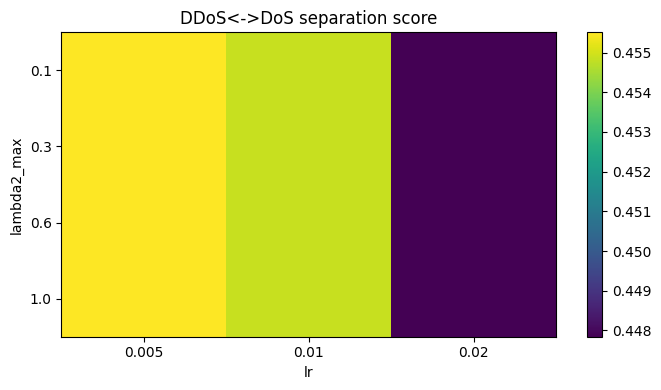

In [ ]:

best_row = sweep_df.iloc[0]
BEST_LAMBDA2 = float(best_row["lambda2_max"])
BEST_LR = float(best_row["lr"])
print(f"best config -> lambda2_max={BEST_LAMBDA2}, lr={BEST_LR}, score={best_row['score']:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
pivot = sweep_df.pivot(index="lambda2_max", columns="lr", values="score")
im = ax.imshow(pivot.values, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
ax.set_xlabel("lr"); ax.set_ylabel("lambda2_max")
ax.set_title("DDoS<->DoS separation score")
plt.colorbar(im); plt.tight_layout(); plt.show()

In [ ]:

epochs = 30
batch_size = 8
lambda1 = 0.5
lambda2 = BEST_LAMBDA2
lr = BEST_LR
early_stopping = True
patience = 5
min_delta = 0.001

ckpt_dir = OUT_DIR / f"{NOTEBOOK_NAME}_seed{SEED}"; ckpt_dir.mkdir(parents=True, exist_ok=True)
latest_ckpt = ckpt_dir / "maqt-latest.pt"
resume_from = latest_ckpt if latest_ckpt.exists() else None
print(f"lambda1={lambda1} lambda2={lambda2} lr={lr}")

torch.manual_seed(SEED)
result = run_batched_safely(
    train_maqt, X_train_angles, y_train,
    n_classes=num_classes, n_qubits=num_qubits, n_layers=num_layers,
    forward_circuit=forward_circuit, device=device,
    epochs=epochs, lr=lr, batch_size=batch_size, min_batch=2, label="train_maqt",
    lambda1_max=lambda1, lambda2_max=lambda2,
    use_weighted_sampler=True, seed=SEED,
    early_stopping=early_stopping, patience=patience, min_delta=min_delta,
    checkpoint_dir=ckpt_dir, save_every_epoch=True,
    resume_from=resume_from, reset_early_stopping_on_resume=True,
    heartbeat_every_steps=50, notebook_name=NOTEBOOK_NAME, log_dir=ckpt_dir,
)
if result is None:
    raise RuntimeError("train_maqt failed even at min_batch (OOM)")
theta_star, classifier_head, prototypes, ema_protos, history = result
safe_empty_cache()
print(f"epochs_ran={history.get('epochs_ran')} best_epoch={history.get('best_epoch')} "
      f"stop_reason={history.get('stop_reason')}")

lambda1=0.5 lambda2=0.1 lr=0.005
	epoch 1 step 50 (2%) loss=1.3858 elapsed=12s eta=646s
	epoch 1 step 100 (4%) loss=1.1738 elapsed=24s eta=634s
	epoch 1 step 150 (5%) loss=1.0532 elapsed=35s eta=622s
	epoch 1 step 200 (7%) loss=0.9518 elapsed=47s eta=611s
	epoch 1 step 250 (9%) loss=0.9752 elapsed=59s eta=602s
	epoch 1 step 300 (11%) loss=1.0878 elapsed=71s eta=589s
	epoch 1 step 350 (13%) loss=0.8406 elapsed=83s eta=577s
	epoch 1 step 400 (14%) loss=0.8335 elapsed=94s eta=565s
	epoch 1 step 450 (16%) loss=0.6656 elapsed=106s eta=554s
	epoch 1 step 500 (18%) loss=0.8770 elapsed=118s eta=542s
	epoch 1 step 550 (20%) loss=0.9154 elapsed=130s eta=530s
	epoch 1 step 600 (21%) loss=0.8966 elapsed=142s eta=519s
	epoch 1 step 650 (23%) loss=0.8043 elapsed=154s eta=507s
	epoch 1 step 700 (25%) loss=0.7660 elapsed=166s eta=495s
	epoch 1 step 750 (27%) loss=0.6444 elapsed=177s eta=483s
	epoch 1 step 800 (29%) loss=0.5866 elapsed=189s eta=471s
	epoch 1 step 850 (30%) loss=0.6069 elapsed=201s eta=

In [11]:
# ============================================================
# CELL 9 — save best model
# ============================================================
ckpt_path = OUT_DIR / f"{NOTEBOOK_NAME}-checkpoint.pt"
torch.save({
    "theta": theta_star.detach().cpu(),
    "head_state_dict": classifier_head.state_dict(),
    "prototypes": {k: v.detach().cpu() for k, v in prototypes.items()},
    "class_names": list(class_names),
    "num_classes": num_classes, "num_qubits": num_qubits, "num_layers": num_layers,
    "noise_rate": noise_rate, "reupload": REUPLOAD, "feature_cols": list(FEATURE_COLS),
    "lambda1": lambda1, "lambda2": lambda2, "lr": lr,
    "scaler": scaler, "pca": pca, "k95": int(k95),
    "angle_x_min": np.asarray(x_min), "angle_x_max": np.asarray(x_max),
    "angle_min": 0.0, "angle_max": float(np.pi),
}, ckpt_path)
print("published:", ckpt_path.resolve())

proto_df = pd.DataFrame(prototype_summary(prototypes, class_names))
proto_df

published: /kaggle/working/models/prototypes/BoT-IoT/maqt-hptuned-bot-iot-checkpoint.pt


,class,dim,trace
0,DDoS,32,1.000001
1,DoS,32,1.000001
2,Normal,32,1.000001
3,Reconnaissance,32,1.000001


test accuracy: 0.6411

                precision    recall  f1-score   support

          DDoS       0.79      0.45      0.57      9411
           DoS       0.59      0.82      0.69      8135
        Normal       0.43      0.96      0.59       691
Reconnaissance       0.85      0.97      0.91       354

      accuracy                           0.64     18591
     macro avg       0.67      0.80      0.69     18591
  weighted avg       0.69      0.64      0.63     18591



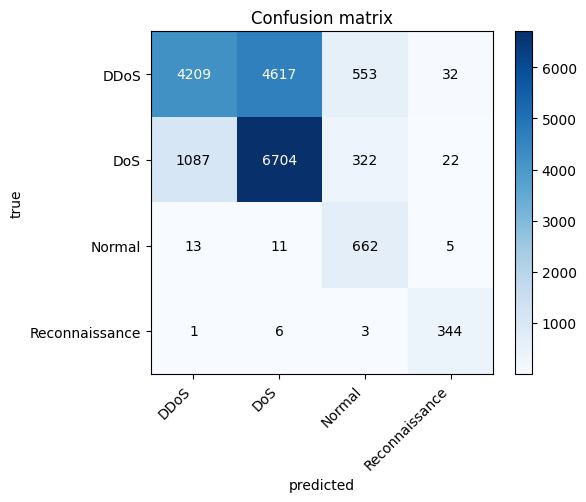

DDoS<->DoS mutual misclassifications: 5704 / 18591


In [ ]:

y_true, y_pred = predict_labels(X_test_angles, y_test_full, theta_star, classifier_head,
                                 forward_circuit, device=device, batch_size=DEFAULT_BATCH_SIZE)
acc = accuracy_score(y_true, y_pred)
print(f"test accuracy: {acc:.4f}\n")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=range(num_classes))
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(num_classes)); ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticks(range(num_classes)); ax.set_yticklabels(class_names)
for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title("Confusion matrix")
plt.colorbar(im); plt.tight_layout(); plt.show()

ddos_dos_confusion = cm[DDOS_ID, DOS_ID] + cm[DOS_ID, DDOS_ID]
print(f"DDoS<->DoS mutual misclassifications: {ddos_dos_confusion} / {cm.sum()}")

In [ ]:

h1_report = hilbert_geometry_diagnostics(
    theta_star, X_test_angles, y_test_full, prototypes, forward_circuit,
    class_names=class_names, device=device, max_per_class=2000, seed=SEED,
)
print_h1_report(h1_report)

print("\nAll pairwise inter-class fidelities / trace distances:")
for row in h1_report["pairs"]:
    flag = "  <-- watch this pair" if "DDoS" in row["pair"] and "DoS" in row["pair"] else ""
    print(f"  {row['pair']:24s} F={row['pair_inter_fid']:.4f}  D_tr={row['pair_trace_distance']:.4f}{flag}")

=== H1 Hilbert geometry (fidelity gaps) ===
mean intra-class fidelity : 0.8403
mean inter-class fidelity : 0.7908
fidelity gap (intra-inter): 0.0495  ← want ↑
mean inter trace distance : 0.5077  ← want ↑

per-class intra fidelity:
  DDoS                         n=2000  F=0.8534
  DoS                          n=2000  F=0.8849
  Normal                       n= 691  F=0.7350
  Reconnaissance               n= 354  F=0.8880

All pairwise inter-class fidelities / trace distances:
  DDoS↔DoS                 F=0.9887  D_tr=0.1129  <-- watch this pair
  DDoS↔Normal              F=0.8232  D_tr=0.4939  <-- watch this pair
  DDoS↔Reconnaissance      F=0.6508  D_tr=0.7064  <-- watch this pair
  DoS↔Normal               F=0.8308  D_tr=0.4879
  DoS↔Reconnaissance       F=0.6495  D_tr=0.7072
  Normal↔Reconnaissance    F=0.8021  D_tr=0.5376


In [ ]:

cache = ForwardCache(store_device="cpu")
entry_cal   = cache.compute("cal",   X_cal_angles,  theta_star, forward_circuit, device=device, batch_size=64)
entry_test  = cache.compute("test",  X_test_angles, theta_star, forward_circuit, device=device, batch_size=64)
entry_zero  = cache.compute("zero",  X_zero_angles, theta_star, forward_circuit, device=device, batch_size=64)

#calibrate conformal threshold q from calibration split
q, scores_sorted = cached_calibrate_threshold(entry_cal, prototypes, alpha=DEFAULT_ALPHA)
print(f"conformal threshold q = {q:.4f} (alpha={DEFAULT_ALPHA}, n_cal={len(scores_sorted)})")

#Lipschitz percentile estimate (for certified radius)
lip = cached_lipschitz_percentile(entry_test, n_pairs=300, percentile=95)
L_phi = lip["p95"]
print(f"L_phi (p95) = {L_phi:.4f}  max_ratio={lip['max']:.4f}")

#unified inference on KNOWN test set
labels_test, radii_test, scores_test, _ = cached_qsnet_infer(
    entry_test, prototypes, q, p=noise_rate, L_phi=L_phi, Cf=DEFAULT_CF, device=device,
)
known_mask = labels_test != ZERO_DAY
known_acc = float(np.mean(labels_test[known_mask] == to_np_y(y_test_full).astype(int)[known_mask])) if known_mask.any() else float("nan")
reject_rate_known = float(np.mean(~known_mask))
print(f"known-test accuracy (non-rejected): {known_acc:.4f}")
print(f"false-alarm (known flagged as zero-day): {reject_rate_known:.4f}")

#  unified inference on ZERO-DAY set
labels_zero, radii_zero, scores_zero, _ = cached_qsnet_infer(
    entry_zero, prototypes, q, p=noise_rate, L_phi=L_phi, Cf=DEFAULT_CF, device=device,
)
zero_day_detection_rate = float(np.mean(labels_zero == ZERO_DAY))
print(f"zero-day detection rate: {zero_day_detection_rate:.4f}  (n={len(labels_zero)})")

# alpha sweep (how the false-alarm rate tracks target alpha)
alpha_sweep_rows = cached_conformal_alpha_sweep(entry_cal, entry_test, prototypes,
                                                 alphas=(0.01, 0.05, 0.1, 0.2))
pd.DataFrame(alpha_sweep_rows)

conformal threshold q = 0.2330 (alpha=0.05, n_cal=18591)
L_phi (p95) = 0.7933  max_ratio=0.8458
known-test accuracy (non-rejected): 0.5966
false-alarm (known flagged as zero-day): 0.0473
zero-day detection rate: 0.5198  (n=683)


,alpha,q,empirical_false_alarm_rate,min_calibration_size,n_cal
0,0.01,0.388214,0.009306,99.0,18591
1,0.05,0.233028,0.047281,19.0,18591
2,0.10,0.190932,0.094938,9.0,18591
3,0.20,0.157533,0.197945,4.0,18591


In [ ]:

log_path = write_history_log(
    history, NOTEBOOK_NAME,
    extra={
        "best_lambda2": BEST_LAMBDA2, "best_lr": BEST_LR,
        "sweep_grid": {"lambda2": LAMBDA2_GRID, "lr": LR_GRID},
        "test_accuracy": acc, "ddos_dos_confusion": int(ddos_dos_confusion),
        "h1_fidelity_gap": h1_report["fidelity_gap"],
        "conformal_q": float(q), "L_phi_p95": float(L_phi),
        "known_test_accuracy_nonrejected": known_acc,
        "zero_day_detection_rate": zero_day_detection_rate,
        "class_names": list(class_names), "seed": SEED,
    },
    log_dir=str(LOG_DIR),
)
print(f"wrote {Path(log_path).resolve()}")

wrote /kaggle/working/logs/maqt-hptuned-bot-iot.log
